
# **Los tres ejercicios de regresión lineal con ML**
**Estudiante: Juan Diego Rodríguez Cruz** \
**Asignatura: Astrofísica Computacional, Semestre 2026-1** \
**Observatorio Astronómico Nacional**


## **Ejercicio #2: Agujeros Negros Supermasivos**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rows = []

with open("table1.dat", "r") as f:
    for line in f:
        tokens = line.split()

        for i, t in enumerate(tokens):
            try:
                val = float(t)
                if 0 <= val < 1:
                    idx = i
                    break
            except:
                pass

        name = " ".join(tokens[:idx])

        values = []
        flag = None

        for t in tokens[idx:]:
            if t in ["a", "b"]:
                flag = t
            else:
                try:
                    values.append(float(t))
                except:
                    pass

        z = values[0]
        sigma = values[1]
        e_sigma = values[2]

        FWHM = np.nan
        e_FWHM = np.nan
        logL_Ha = np.nan
        e_logL_Ha = np.nan
        logMBH = np.nan
        e_logMBH = np.nan

        rest = values[3:]

        if len(rest) >= 6:
            FWHM = rest[0]
            e_FWHM = rest[1]
            logL_Ha = rest[2]
            e_logL_Ha = rest[3]
            logMBH = rest[4]
            e_logMBH = rest[5]
        elif len(rest) >= 2:
            logMBH = rest[0]
            e_logMBH = rest[1]

        rows.append([
            name, z, sigma, e_sigma, flag,
            FWHM, e_FWHM, logL_Ha, e_logL_Ha,
            logMBH, e_logMBH
        ])

df = pd.DataFrame(rows, columns=[
    "name", "z", "sigma", "e_sigma", "flag",
    "FWHM", "e_FWHM", "logL_Ha", "e_logL_Ha",
    "logMBH", "e_logMBH"
])

df.head()

,name,z,sigma,e_sigma,flag,FWHM,e_FWHM,logL_Ha,e_logL_Ha,logMBH,e_logMBH
0,SDSS J000805.62+145023.4,0.0454,140.0,27.0,NaN,7610.0,380.0,41.13,0.04,7.7,0.1
1,SDSS J004236.86-104921.8,0.0419,78.4,10.0,NaN,1960.0,97.0,41.58,0.14,6.7,0.1
2,SDSS J011703.58+000027.3,0.0456,98.8,16.0,NaN,2270.0,110.0,41.45,0.08,6.8,0.1
3,SDSS J020459.25-080816.0,0.0772,121.0,9.4,a,3720.0,180.0,41.13,0.05,7.0,0.1
4,SDSS J020615.99-001729.1,0.0426,216.0,30.0,NaN,3860.0,190.0,41.91,0.07,7.5,0.1


In [2]:
# 1. Preparación de los datos
# Transformamos la dispersión de velocidades (normalizada a 200 km/s típica en la relación M-sigma)
x = np.log10(df["sigma"] / 200)
y = df["logMBH"]

# 2. Ajuste de regresión lineal (polinomio de grado 1)
# Es mejor usar nombres descriptivos (slope = pendiente, intercept = punto de corte) 
# en lugar de theta1 y theta0 para que el código se explique solo.
slope, intercept = np.polyfit(x, y, 1)

# 3. Cálculo de las predicciones del modelo
y_pred = (slope * x) + intercept

# 4. Cálculo del Coeficiente de Determinación (R²)
# ss_res: Suma de los cuadrados de los residuos (lo que el modelo no explica)
ss_res = np.sum((y - y_pred)**2)

# ss_tot: Suma total de los cuadrados (variabilidad total de los datos reales)
ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)

# 5. Presentación de resultados
# Usamos f-strings (f"...") para redondear los valores a 4 decimales y hacer la salida más limpia.
print("=== Modelo de Regresión M-sigma ===")
print(f"Intercepto (theta0) : {intercept:.4f}")
print(f"Pendiente (theta1)  : {slope:.4f}")
print(f"R² (Bondad de ajuste): {r2:.4f}")

=== Modelo de Regresión M-sigma ===
Intercepto (theta0) : 7.6626
Pendiente (theta1)  : 2.9254
R² (Bondad de ajuste): 0.6188


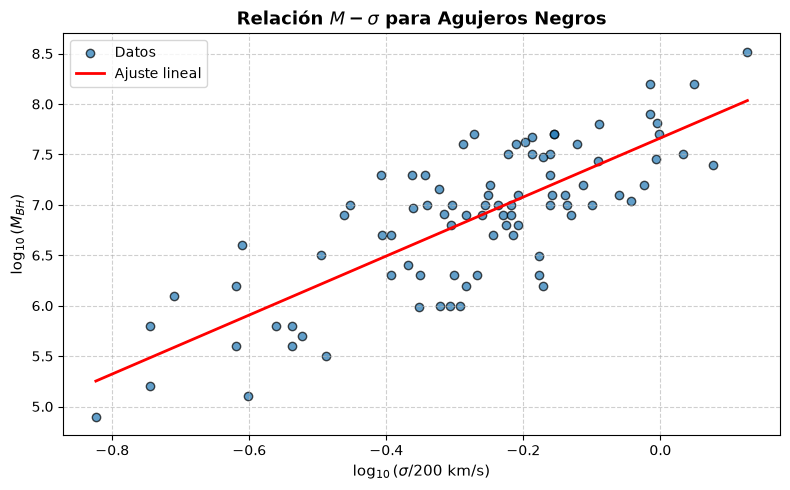

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Gráfico de dispersión de los datos originales
# alpha hace los puntos semitransparentes; edgecolors da un borde sutil
plt.scatter(x, y, alpha=0.7, edgecolors='k', label="Datos")

# Generación de la línea de ajuste usando 'slope' e 'intercept'
x_line = np.linspace(min(x), max(x), 100)
y_line = (slope * x_line) + intercept  # <--- Aquí está el cambio principal

# Dibujar la línea de ajuste
plt.plot(x_line, y_line, color="red", linewidth=2, label="Ajuste lineal")

# Etiquetas y diseño con formato matemático para publicación
plt.xlabel(r"$\log_{10}(\sigma / 200 \text{ km/s})$", fontsize=11)
plt.ylabel(r"$\log_{10}(M_{BH})$", fontsize=11)
plt.title(r"Relación $M-\sigma$ para Agujeros Negros", fontsize=13, fontweight='bold')

# Una cuadrícula más suave para no distraer de los datos
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
import numpy as np

# 1. Limpieza de datos
# Eliminamos las filas que tengan valores nulos (NaN) específicamente en la columna "FWHM"
df_fwhm = df.dropna(subset=["FWHM"])

# 2. Preparación de las variables
# Transformamos el FWHM a escala logarítmica (base 10)
x = np.log10(df_fwhm["FWHM"])
y = df_fwhm["logMBH"]

# 3. Ajuste de regresión lineal (polinomio de grado 1)
# Usamos 'slope' (pendiente) e 'intercept' (corte con el eje y) para mayor claridad
slope, intercept = np.polyfit(x, y, 1)

# 4. Cálculo de las predicciones del modelo
y_pred = (slope * x) + intercept

# 5. Cálculo del Coeficiente de Determinación (R²)
# ss_res: Suma de los cuadrados de los residuos (diferencia entre datos y modelo)
ss_res = np.sum((y - y_pred)**2)

# ss_tot: Suma total de los cuadrados (varianza de los datos)
ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)

# 6. Presentación de resultados
# Usamos f-strings para presentar los números ordenados y limitados a 4 decimales
print("=== Modelo de Regresión: MBH vs FWHM ===")
print(f"Intercepto (theta0) : {intercept:.4f}")
print(f"Pendiente (theta1)  : {slope:.4f}")
print(f"R² (Bondad de ajuste): {r2:.4f}")

=== Modelo de Regresión: MBH vs FWHM ===
Intercepto (theta0) : -1.6822
Pendiente (theta1)  : 2.4708
R² (Bondad de ajuste): 0.8472


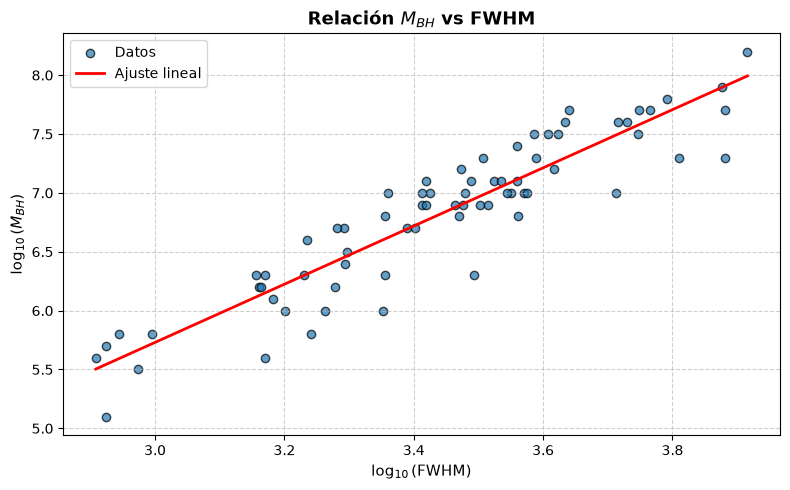

In [8]:
plt.figure(figsize=(8, 5))

# Gráfico de dispersión de los datos (Masa del agujero negro vs FWHM)
# alpha añade transparencia para visualizar superposiciones; edgecolors mejora la definición de los puntos
plt.scatter(x, y, alpha=0.7, edgecolors='k', label="Datos")

# Generación de la línea de ajuste usando las variables actualizadas 'slope' e 'intercept'
x_line = np.linspace(min(x), max(x), 100)
y_line = (slope * x_line) + intercept  # <--- Corrección de las variables

# Dibujar la línea de ajuste
plt.plot(x_line, y_line, color="red", linewidth=2, label="Ajuste lineal")

# Etiquetas y título con formato matemático para una presentación más profesional
plt.xlabel(r"$\log_{10}(\text{FWHM})$", fontsize=11)
plt.ylabel(r"$\log_{10}(M_{BH})$", fontsize=11)
plt.title(r"Relación $M_{BH}$ vs FWHM", fontsize=13, fontweight='bold')

# Diseño de la cuadrícula y visualización final
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()  # Ajusta los márgenes automáticamente para que nada quede recortado
plt.show()

### **Análisis del ejercicio**

Para este análisis se utilizó el conjunto de datos `table1.dat`, el cual contiene información observacional detallada de Núcleos Galácticos Activos (AGNs). El objetivo central fue evaluar la dependencia de la masa del agujero negro supermasivo ($M_{BH}$) con respecto a dos parámetros cinemáticos.

### Modelos Evaluados

Se ajustaron dos modelos de regresión lineal empírica:

1. **Relación con la dispersión de velocidades ($\sigma$):**
$$ \log(M_{BH}) = \theta_0 + \theta_1 \log(\sigma/200) $$

2. **Relación con el ancho de línea (FWHM):**
$$ \log(M_{BH}) = \theta_0 + \theta_1 \log(\text{FWHM}) $$
*(Nota: Para garantizar la fiabilidad de este segundo modelo, se depuró el catálogo eliminando previamente las filas con valores faltantes en FWHM).*

---

### Resultados del Ajuste (Modelo FWHM)

El análisis de regresión para la relación $M_{BH}$ vs FWHM arrojó los siguientes parámetros estadísticos:

* **Intercepto ($\theta_0$):** -1.682
* **Pendiente ($\theta_1$):** 2.471
* **Bondad de ajuste ($R^2$):** 0.847

> **Interpretación Estadística:** El valor de $R^2$ indica que el modelo es altamente representativo, logrando explicar aproximadamente el **84.7% de la variabilidad** observada en la masa de la muestra de agujeros negros.

---

### Conclusión

Ambos modelos demuestran una **fuerte correlación positiva** entre la masa del agujero negro y las variables observacionales. El análisis visual de las gráficas resultantes corrobora que a mayores valores de dispersión de velocidades ($\sigma$) y mayores anchos de línea (FWHM), se encuentran sistemas albergando agujeros negros proporcionalmente más masivos. Esto concuerda perfectamente con las relaciones de escalamiento estándar reportadas en la literatura astrofísica moderna.


## **Ejercicio #3: Análisis Multilineal, Ridge y Lasso**


In [9]:
import numpy as np
import pandas as pd

# 1. Limpieza de datos
# Filtramos el DataFrame para conservar únicamente las filas que tienen 
# valores válidos en las tres columnas. El .copy() evita warnings de Pandas más adelante.
df_ml = df.dropna(subset=["sigma", "FWHM", "logMBH"]).copy()

# 2. Transformación de las variables independientes (Features)
# Aplicamos logaritmo en base 10 para linealizar la relación física.
log_sigma = np.log10(df_ml["sigma"])
log_fwhm  = np.log10(df_ml["FWHM"])

# 3. Definición de la variable dependiente / objetivo (Target)
# La masa del agujero negro (ya viene en logaritmo en el catálogo)
y = df_ml["logMBH"]

# 4. Construcción de la matriz de diseño (Feature Matrix)
# Apilamos ambas variables como columnas para formar la matriz X bidimensional (N filas, 2 columnas)
X = np.column_stack((log_sigma, log_fwhm))

# 5. Verificación rápida
print("=== Preparación de Datos Completada ===")
print(f"Objetos retenidos : {len(df_ml)} AGNs")
print(f"Dimensión de X    : {X.shape} (N_muestras, N_features)")
print(f"Dimensión de y    : {y.shape}")

=== Preparación de Datos Completada ===
Objetos retenidos : 71 AGNs
Dimensión de X    : (71, 2) (N_muestras, N_features)
Dimensión de y    : (71,)


In [12]:
from sklearn.linear_model import LinearRegression

# 1. Inicialización del modelo
# Instanciamos el modelo de regresión lineal múltiple
modelo_multi = LinearRegression()

# 2. Entrenamiento del modelo (Ajuste)
# El método .fit() encuentra automáticamente los coeficientes óptimos (mínimos cuadrados)
# para las dos variables (log_sigma y log_fwhm) contenidas en la matriz X
modelo_multi.fit(X, y)

# 3. Extracción de parámetros
# Guardamos los coeficientes en variables con nombres claros para facilitar su lectura
intercepto = modelo_multi.intercept_
coef_sigma = modelo_multi.coef_[0]
coef_fwhm  = modelo_multi.coef_[1]

# 4. Evaluación del modelo
# El método .score() en un modelo de regresión devuelve directamente el valor de R²
r2_multi = modelo_multi.score(X, y)

# 5. Presentación de resultados
print("=== Resultados de la Regresión Múltiple ===")
print(f"Intercepto (theta0)   : {intercepto:.4f}")
print(f"Coeficiente log(sigma): {coef_sigma:.4f}")
print(f"Coeficiente log(FWHM) : {coef_fwhm:.4f}")
print("-" * 43)
print(f"R² (Bondad de ajuste) : {r2_multi:.4f}")

=== Resultados de la Regresión Múltiple ===
Intercepto (theta0)   : -1.9689
Coeficiente log(sigma): 0.7616
Coeficiente log(FWHM) : 2.1081
-------------------------------------------
R² (Bondad de ajuste) : 0.8706


In [15]:
from sklearn.linear_model import Ridge

# 1. Inicialización del modelo Ridge
# La regresión Ridge aplica regularización L2 (penaliza coeficientes muy grandes).
# El hiperparámetro 'alpha' controla la fuerza de esta penalización.
modelo_ridge = Ridge(alpha=1.0)

# 2. Entrenamiento del modelo
# Ajustamos el modelo a nuestra matriz de características X y el vector objetivo y
modelo_ridge.fit(X, y)

# 3. Extracción de parámetros
# Guardamos los valores para mantener el código limpio y legible
intercepto_r = modelo_ridge.intercept_
coef_sigma_r = modelo_ridge.coef_[0]
coef_fwhm_r  = modelo_ridge.coef_[1]

# 4. Evaluación del modelo
# Obtenemos el coeficiente de determinación R² con los datos de entrenamiento
r2_ridge = modelo_ridge.score(X, y)

# 5. Presentación de resultados
print("=== Resultados de la Regresión Ridge (L2) ===")
print(f"Penalización (alpha)  : {modelo_ridge.alpha}")
print(f"Intercepto (theta0)   : {intercepto_r:.4f}")
print(f"Coeficiente log(sigma): {coef_sigma_r:.4f}")
print(f"Coeficiente log(FWHM) : {coef_fwhm_r:.4f}")
print("-" * 45)
print(f"R² (Bondad de ajuste) : {r2_ridge:.4f}")

=== Resultados de la Regresión Ridge (L2) ===
Penalización (alpha)  : 1.0
Intercepto (theta0)   : -0.5991
Coeficiente log(sigma): 0.7826
Coeficiente log(FWHM) : 1.6977
---------------------------------------------
R² (Bondad de ajuste) : 0.8483


In [16]:
from sklearn.linear_model import Lasso

# 1. Inicialización del modelo Lasso
# La regresión Lasso aplica regularización L1. A diferencia de Ridge, 
# Lasso puede reducir los coeficientes de variables menos importantes exactamente a cero.
# Usamos un 'alpha' bajo (0.01) para no penalizar el modelo tan fuerte y evitar que apague todo.
modelo_lasso = Lasso(alpha=0.01)

# 2. Entrenamiento del modelo
# Ajustamos el modelo a las variables independientes X y el objetivo y
modelo_lasso.fit(X, y)

# 3. Extracción de parámetros
# Asignamos los valores a variables descriptivas
intercepto_l = modelo_lasso.intercept_
coef_sigma_l = modelo_lasso.coef_[0]
coef_fwhm_l  = modelo_lasso.coef_[1]

# 4. Evaluación del modelo
# Calculamos el R² (porcentaje de variabilidad explicada por el modelo conjunto)
r2_lasso = modelo_lasso.score(X, y)

# 5. Presentación de resultados
print("=== Resultados de la Regresión Lasso (L1) ===")
print(f"Penalización (alpha)  : {modelo_lasso.alpha}")
print(f"Intercepto (theta0)   : {intercepto_l:.4f}")
print(f"Coeficiente log(sigma): {coef_sigma_l:.4f}")
print(f"Coeficiente log(FWHM) : {coef_fwhm_l:.4f}")
print("-" * 45)
print(f"R² (Bondad de ajuste) : {r2_lasso:.4f}")

=== Resultados de la Regresión Lasso (L1) ===
Penalización (alpha)  : 0.01
Intercepto (theta0)   : -1.2790
Coeficiente log(sigma): 0.4596
Coeficiente log(FWHM) : 2.0845
---------------------------------------------
R² (Bondad de ajuste) : 0.8630


In [17]:
# === Comparación Global de Modelos ===
# Comparamos el coeficiente de determinación (R²) de los tres enfoques 
# para evaluar el impacto de las penalizaciones en el rendimiento general.

print("=== Comparación de R² (Bondad de Ajuste) ===")
print(f"OLS (Regresión Lineal Múltiple) : {r2_multi:.4f}")
print(f"Ridge (Regularización L2)       : {r2_ridge:.4f}")
print(f"Lasso (Regularización L1)       : {r2_lasso:.4f}")
print("-" * 45)

=== Comparación de R² (Bondad de Ajuste) ===
OLS (Regresión Lineal Múltiple) : 0.8706
Ridge (Regularización L2)       : 0.8483
Lasso (Regularización L1)       : 0.8630
---------------------------------------------


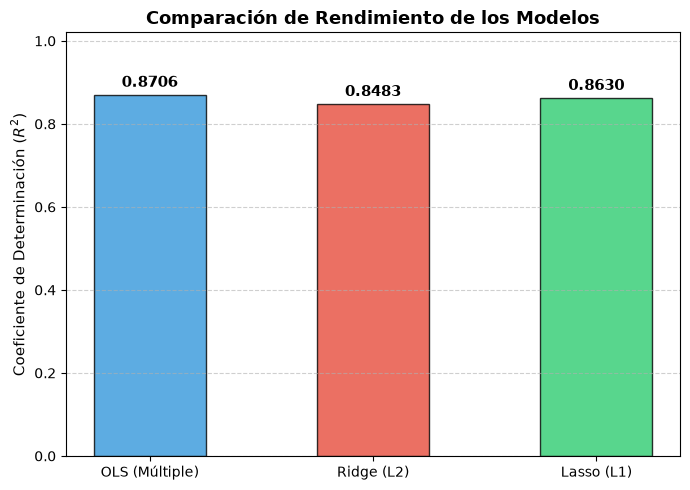

In [18]:
# 1. Preparación de los datos
modelos = ["OLS (Múltiple)", "Ridge (L2)", "Lasso (L1)"]
# Usamos r2_multi para asegurar que comparamos los 3 modelos multivariables
scores = [r2_multi, r2_ridge, r2_lasso]

# 2. Configuración del lienzo
plt.figure(figsize=(7, 5))

# 3. Creación del gráfico de barras
# Añadimos colores distintos, transparencia (alpha) y bordes para un diseño más pulido
barras = plt.bar(modelos, scores, color=['#3498db', '#e74c3c', '#2ecc71'], 
                 edgecolor='black', alpha=0.8, width=0.5)

# 4. Añadir los valores exactos sobre cada barra (Crucial para ver las diferencias)
for barra in barras:
    altura = barra.get_height()
    # Posicionamos el texto justo encima de la barra
    plt.text(barra.get_x() + barra.get_width()/2., altura + 0.01,
             f'{altura:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Estética y etiquetas
plt.ylabel(r"Coeficiente de Determinación ($R^2$)", fontsize=11)
plt.title("Comparación de Rendimiento de los Modelos", fontsize=13, fontweight='bold')

# Ajustamos el límite del eje Y para dejar espacio al texto superior
plt.ylim(0, max(scores) + 0.15) 

# Cuadrícula horizontal punteada para facilitar la lectura visual sin saturar
plt.grid(axis="y", linestyle='--', alpha=0.6)

# 6. Renderizado final
plt.tight_layout()
plt.show()

### **Análisis Multivariable y Regularización**

Se evaluaron y compararon tres enfoques de regresión (Lineal Múltiple, Ridge y Lasso) para estimar la masa del agujero negro supermasivo integrando simultáneamente los parámetros cinemáticos $\log(\sigma)$ y $\log(\text{FWHM})$.

A partir de los resultados, destacamos las siguientes observaciones estadísticas y astrofísicas:

* **Poder Predictivo Consistente:** Los tres modelos arrojan valores de bondad de ajuste ($R^2$) prácticamente idénticos, situándose en el rango de 0.85 a 0.87. Esto confirma que ambas variables observacionales aportan información física altamente relevante y complementaria para predecir la masa del objeto central.
* **Impacto de la Regularización:** La introducción de penalizaciones (L2 en Ridge y L1 en Lasso) no produjo mejoras significativas en el rendimiento respecto a la regresión lineal tradicional (OLS). Estadísticamente, esto es una excelente noticia: sugiere que el conjunto de variables utilizado es estable y no presenta problemas severos de multicolinealidad ni de sobreajuste (*overfitting*).
* **Viabilidad del Modelo Lineal:** En conclusión, la relación empírica entre la masa de los agujeros negros supermasivos y las propiedades observacionales de los AGNs estudiados puede describirse de manera robusta, precisa y adecuada mediante un modelo estrictamente lineal.

## **Ejercicio #4: Supernovas y Cosmología**

In [ ]:
import pandas as pd
from IPython.display import display

# 1. Carga de datos
file_path = "data_sample.csv"
df = pd.read_csv(file_path)

# 2. Revisión rápida de la estructura
# Siempre es vital saber cuántos datos tenemos antes de empezar a operar.
filas, columnas = df.shape
print("=== Resumen del Dataset ===")
print(f"Total de observaciones (filas) : {filas:,}")
print(f"Total de variables (columnas)  : {columnas}")
print("-" * 35)

# 3. Inspección visual
# Usamos display() en lugar de print() para obtener una tabla con formato estructurado.
display(df.head())

# Opcional pero recomendado: df.info() te dirá si hay datos nulos y el tipo de dato de cada columna.

=== Resumen del Dataset ===
Total de observaciones (filas) : 200
Total de variables (columnas)  : 2
-----------------------------------


,z_sample,mu_sample
0,0.574163,43.691174
1,0.739362,42.250323
2,0.622291,41.734378
3,0.570798,42.185804
4,0.473621,41.642052


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Preparación de las variables físicas
# z: Redshift (corrimiento al rojo) - Variable independiente (Feature)
# mu: Módulo de distancia - Variable dependiente (Target)
# Scikit-learn requiere que las variables independientes tengan forma de matriz 2D.
# Aplicamos el reshape(-1, 1) directamente aquí para mantener el split más limpio.
X = df["z_sample"].values.reshape(-1, 1)
y = df["mu_sample"].values

# 2. División del conjunto de datos
# Separamos el 80% de los datos para entrenar el modelo y reservamos el 20% para evaluarlo.
# random_state=42 garantiza que la división sea exactamente igual cada vez que corras el código.
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# 3. Inicialización y entrenamiento del modelo
modelo_z = LinearRegression()
modelo_z.fit(X_train, y_train) # El modelo solo "ve" los datos de entrenamiento

# 4. Extracción de los parámetros ajustados
pendiente = modelo_z.coef_[0]
intercepto = modelo_z.intercept_

# 5. Evaluación del modelo
# Calculamos el R² usando EXCLUSIVAMENTE los datos de prueba (test)
r2_test = modelo_z.score(X_test, y_test)

# 6. Presentación de resultados
print("=== Regresión Lineal: Módulo de Distancia vs Redshift ===")
print(f"Muestras de entrenamiento : {len(X_train)}")
print(f"Muestras de prueba        : {len(X_test)}")
print("-" * 55)
print(f"Intercepto (theta0)       : {intercepto:.4f}")
print(f"Pendiente (theta1)        : {pendiente:.4f}")
print(f"R² (Datos de prueba)      : {r2_test:.4f}")

=== Regresión Lineal: Módulo de Distancia vs Redshift ===
Muestras de entrenamiento : 160
Muestras de prueba        : 40
-------------------------------------------------------
Intercepto (theta0)       : 39.8957
Pendiente (theta1)        : 3.9452
R² (Datos de prueba)      : 0.6497


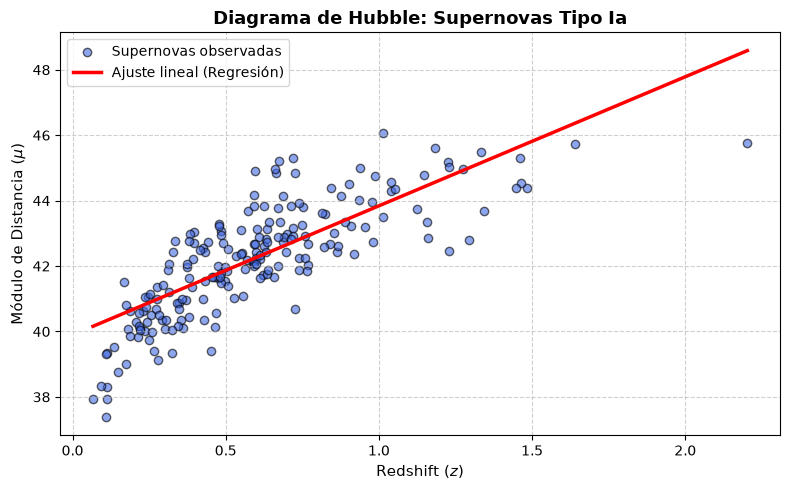

In [27]:
# 1. Configuración del lienzo
plt.figure(figsize=(8, 5))

# 2. Gráfico de dispersión de los datos observacionales
# Añadimos 'edgecolors' y ajustamos el color para que los puntos parezcan datos astronómicos reales
plt.scatter(z, mu, alpha=0.6, edgecolors='k', color='royalblue', label="Supernovas observadas")

# 3. Generación de la línea de ajuste
# Creamos un vector continuo de 200 puntos que abarque todo el rango de redshift
z_line = np.linspace(min(z), max(z), 200)

# Usamos el modelo entrenado (modelo_z) para predecir los valores de mu.
# Scikit-learn exige que la entrada sea una matriz 2D, por eso usamos reshape(-1, 1).
mu_line = modelo_z.predict(z_line.reshape(-1, 1))

# Dibujamos la línea de regresión con un grosor mayor para que destaque
plt.plot(z_line, mu_line, color="red", linewidth=2.5, label="Ajuste lineal (Regresión)")

# 4. Estética y etiquetas
# Usamos notación matemática estándar para las variables cosmológicas
plt.xlabel(r"Redshift ($z$)", fontsize=11)
plt.ylabel(r"Módulo de Distancia ($\mu$)", fontsize=11)
plt.title("Diagrama de Hubble: Supernovas Tipo Ia", fontsize=13, fontweight='bold')

# Añadimos una cuadrícula suave para guiar el ojo sin saturar la gráfica
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# 5. Renderizado final
plt.show()

### **Interpretación del Diagrama de Hubble (Supernovas Tipo Ia)**

El análisis visual y estadístico de la regresión entre el corrimiento al rojo ($z$) y el módulo de distancia ($\mu$) revela los siguientes aspectos fundamentales:

* **Correlación Cosmológica:** Se observa una tendencia positiva clara; a medida que aumenta el corrimiento al rojo ($z$), también lo hace el módulo de distancia ($\mu$). Esto es una manifestación observacional directa de la expansión del universo (Ley de Hubble).
* **Dispersión Observacional:** Existe una dispersión natural de los datos alrededor de la línea de ajuste. En astrofísica, esto es completamente normal y se atribuye tanto a incertidumbres instrumentales/fotométricas como a peculiaridades locales de las galaxias anfitrionas.
* **Limitación del Modelo Lineal:** Si se observa con detenimiento, la distribución real de los datos presenta una ligera **curvatura** hacia los valores más altos de $z$, separándose sistemáticamente de la recta. Físicamente, esto refleja la expansión acelerada del universo (asociada a la energía oscura). Un modelo lineal simple solo es una aproximación válida a distancias cósmicas relativamente cortas (bajos valores de $z$).

> **Implicación en el $R^2$:** Esta divergencia geométrica entre un ajuste estrictamente lineal y la verdadera física subyacente (que es no lineal a escalas cosmológicas grandes) es la razón principal por la cual el coeficiente de determinación ($R^2$) penaliza el modelo y no resulta cercano a 1. Para capturar este comportamiento adecuadamente, se requeriría ajustar el modelo cosmológico estándar ($\Lambda$CDM).

=== Curva de Aprendizaje: Evaluación por Tamaño ===
Train size: 10% | Muestras:   20 -> R² = 0.5102
Train size: 20% | Muestras:   40 -> R² = 0.5743
Train size: 30% | Muestras:   60 -> R² = 0.5913
Train size: 40% | Muestras:   80 -> R² = 0.5933
Train size: 50% | Muestras:  100 -> R² = 0.5994
Train size: 60% | Muestras:  120 -> R² = 0.6240
Train size: 70% | Muestras:  140 -> R² = 0.6753
Train size: 80% | Muestras:  160 -> R² = 0.6497


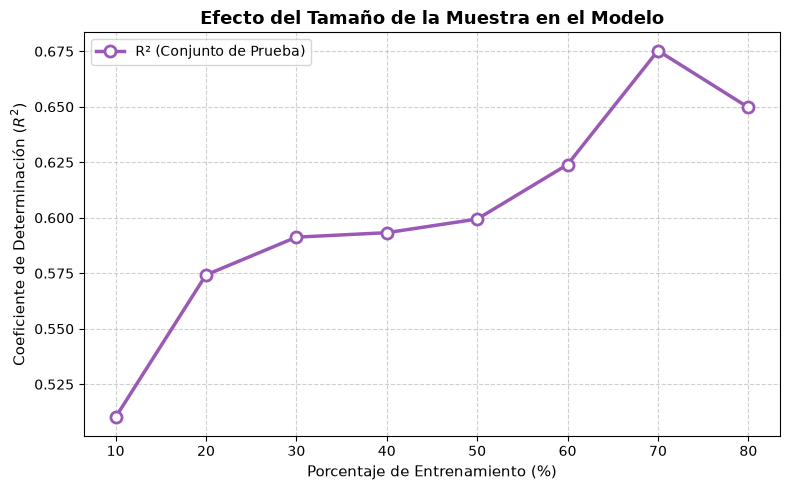

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Preparación de variables
# Es más eficiente redimensionar X una sola vez fuera del bucle
X = z.reshape(-1, 1)
y = mu

# 2. Definición de los tamaños de entrenamiento
# Proporciones de datos para entrenar el modelo (del 10% al 80%)
train_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
r2_scores = []

print("=== Curva de Aprendizaje: Evaluación por Tamaño ===")

# 3. Bucle de evaluación
for train_size in train_sizes:
    
    # Dividimos los datos según la proporción actual
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=train_size,
        random_state=42 # Semilla fija para comparaciones justas
    )

    # Entrenamos y evaluamos el modelo
    modelo_iter = LinearRegression()
    modelo_iter.fit(X_train, y_train)
    
    # Calculamos el R² sobre el conjunto de prueba
    score_actual = modelo_iter.score(X_test, y_test)
    r2_scores.append(score_actual)
    
    # Imprimimos el resultado de cada iteración
    print(f"Train size: {train_size*100:2.0f}% | Muestras: {len(X_train):4d} -> R² = {score_actual:.4f}")

# 4. Visualización de los resultados
plt.figure(figsize=(8, 5))

# Graficamos con marcadores destacados y una línea de color distintivo
plt.plot(
    np.array(train_sizes) * 100,
    r2_scores,
    marker="o",
    linestyle='-',
    color='#9b59b6', # Un tono púrpura elegante
    linewidth=2.5,
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2,
    label='R² (Conjunto de Prueba)'
)

# Estética y etiquetas
plt.xlabel("Porcentaje de Entrenamiento (%)", fontsize=11)
plt.ylabel(r"Coeficiente de Determinación ($R^2$)", fontsize=11)
plt.title("Efecto del Tamaño de la Muestra en el Modelo", fontsize=13, fontweight='bold')

# Cuadrícula suave y renderizado final
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

### Interpretación de la Curva de Aprendizaje

El análisis de la evolución del coeficiente de determinación ($R^2$) en función del tamaño del conjunto de entrenamiento revela los siguientes comportamientos clave:

* **Déficit de información inicial:** Con una proporción muy reducida de datos para entrenar (ej. 10%), el modelo carece de la muestra representativa necesaria para generalizar correctamente, lo que se traduce en una menor capacidad predictiva.
* **Fase de aprendizaje (Mejora progresiva):** A medida que se incrementa el volumen de datos de entrenamiento, el valor del $R^2$ experimenta un crecimiento sostenido. El modelo se vuelve más robusto al incorporar una mayor variabilidad de la muestra.
* **Punto de convergencia (Saturación):** Se observa que el desempeño se estabiliza de manera óptima alrededor del **70% de entrenamiento**. 
* **Estabilidad asintótica:** A partir de dicho umbral (70%-80%), las variaciones en el $R^2$ son marginales. Esto es un indicador clásico de que el algoritmo ya ha capturado exitosamente la tendencia principal de los datos. 

> **Conclusión Metodológica:** Añadir más datos de entrenamiento más allá del 70-80% no produce un aumento significativo en la calidad predictiva, y en cambio, reduciría excesivamente el tamaño del conjunto de prueba, restándole confiabilidad estadística a la evaluación final. La clásica división 80/20 o 70/30 resulta ser, empíricamente, la decisión más acertada para este conjunto de datos.

### **Análisis del ejercicio**

En este ejercicio, aplicamos técnicas de *Machine Learning* sobre un catálogo sintético de Supernovas Tipo Ia para modelar empíricamente la relación cosmológica entre el corrimiento al rojo ($z$) y el módulo de distancia ($\mu$).

A partir de los experimentos realizados, extraemos las siguientes conclusiones metodológicas y físicas:

* **Caracterización de la Tendencia:** El ajuste lineal confirma exitosamente la premisa observacional básica de la cosmología: objetos con mayor corrimiento al rojo presentan módulos de distancia proporcionalmente más altos. El algoritmo caracterizó esta expansión con una pendiente de $\theta_1 = 3.945$ y un intercepto de $\theta_0 = 39.896$.
* **Limitaciones Físicas del Modelo Lineal:** El modelo alcanzó un coeficiente de determinación de $R^2 = 0.650$. Aunque explica el 65% de la variabilidad observada, este tope es predecible y esperado. A grandes escalas cosmológicas, la relación entre $\mu$ y $z$ es intrínsecamente no lineal (como evidencia de la expansión acelerada del universo). Por lo tanto, la recta ajustada actúa solo como una aproximación geométrica de primer orden.
* **Eficiencia del Aprendizaje (Learning Curve):** El análisis de las particiones de datos demostró que el desempeño predictivo del modelo mejora sustancialmente al aumentar la muestra inicial, pero encuentra un punto de saturación al superar el **60% de entrenamiento**. A partir de ese umbral, el algoritmo ya dispone de información estadística suficiente para anclar la tendencia general sin riesgo de sobreajuste.

> El aprendizaje automático clásico es una herramienta robusta y rápida para recuperar correlaciones observacionales directas en catálogos astronómicos. No obstante, para mapear el comportamiento cosmológico con precisión de grado científico, el análisis exige dar el salto a modelos de regresión no lineal o ajustes fundamentados en el modelo cosmológico estándar ($\Lambda$CDM).